# Warehouse

In [4]:
import sqlite3
import pandas as pd

target_db = 'GreatOutdoors/SDM.sqlite'
target_WH_db = 'GreatOutdoors/Warehouse.sqlite'
# Connections
sdm_conn = sqlite3.connect(target_db)
dwh_conn = sqlite3.connect(target_WH_db)



## Customer Headquarters

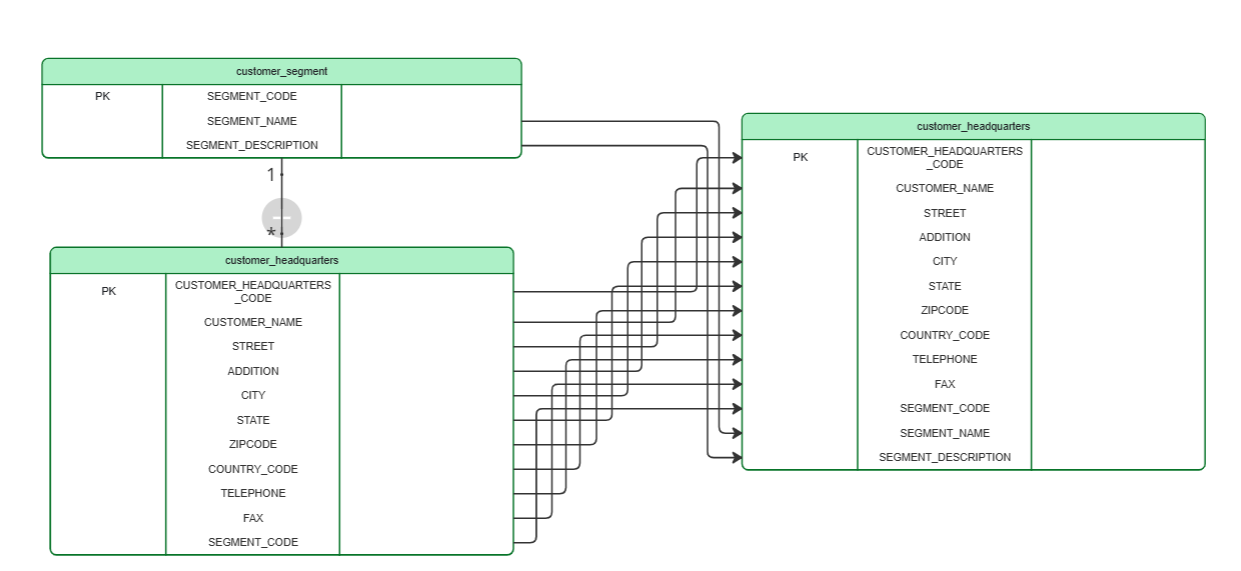

In [ ]:
df_customer_segment            = pd.read_sql_query("SELECT * FROM Customer_Segment", sdm_conn)
df_sales_demographic = pd.read_sql_query("SELECT * FROM Sales_Demographic", sdm_conn)

df_sales_demographic_final = pd.merge(
    df_sales_demographic,
    df_age_group,
    left_on='AGE_GROUP_CODE',
    right_on='AGE_GROUP_CODE',
    how='left')
df_sales_demographic_final = df_sales_demographic_final[[
    'DEMOGRAPHIC_CODE',
    'CUSTOMER_CODEMR',
    'SALES_PERCENT',
    'LOWER_AGE',
    'UPPER_AGE'
]]

df_sales_demographic_final

## Sales Demographic

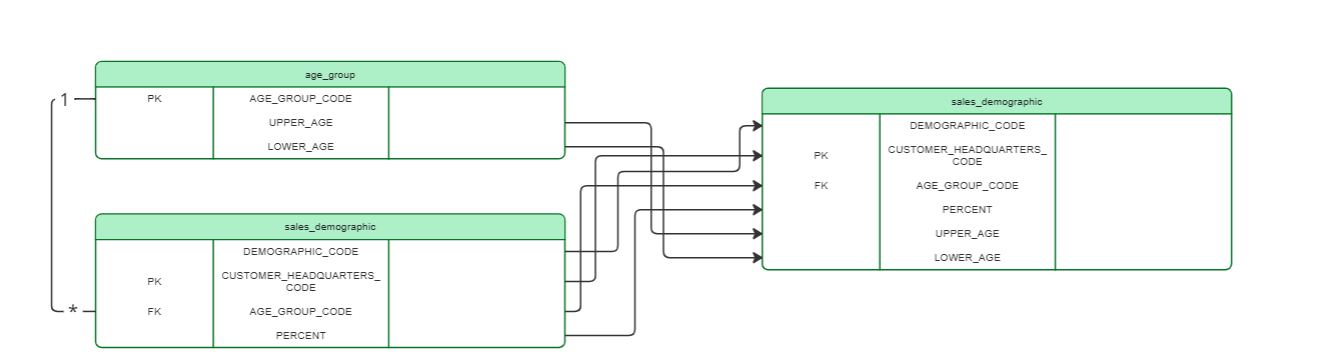

In [23]:
df_age_group            = pd.read_sql_query("SELECT * FROM Age_Group", sdm_conn)
df_sales_demographic = pd.read_sql_query("SELECT * FROM Sales_Demographic", sdm_conn)

df_sales_demographic_final = pd.merge(
    df_sales_demographic,
    df_age_group,
    left_on='AGE_GROUP_CODE',
    right_on='AGE_GROUP_CODE',
    how='left')
df_sales_demographic_final = df_sales_demographic_final[[
    'DEMOGRAPHIC_CODE',
    'CUSTOMER_CODEMR',
    'SALES_PERCENT',
    'LOWER_AGE',
    'UPPER_AGE'
]]

df_sales_demographic_final

,DEMOGRAPHIC_CODE,CUSTOMER_CODEMR,SALES_PERCENT,LOWER_AGE,UPPER_AGE
0,2475,405,25,41,50
1,2476,405,23,51,60
2,2477,405,24,61,70
3,2478,412,2,0,20
4,2479,412,4,21,30
...,...,...,...,...,...
2479,2470,627,10,51,60
2480,2471,627,0,61,70
2481,2472,405,0,0,20
2482,2473,405,6,21,30


In [ ]:
import sqlite3
import pandas as pd

# 1. ALWAYS re-open the connection at the start of the test cell
dwh_conn = sqlite3.connect(target_WH_db) # Double check your filename!

try:
    # Read the current state of the Warehouse
    df_dwh = pd.read_sql("SELECT * FROM Accessoire", dwh_conn)

    # 2. DETECT NEW ROWS
    new_rows = df_accessoire_final[~df_accessoire_final['accessoirenr'].isin(df_dwh['accessoirenr'])]

    # 3. DETECT CHANGES (Compare names as well now!)
    comparison = pd.merge(
        df_accessoire_final, 
        df_dwh, 
        on='accessoirenr', 
        suffixes=('_src', '_dwh')
    )

    # We check if Name OR Address OR Supplier Name changed
    changed_mask = (comparison['naam_src'] != comparison['naam_dwh']) | \
                   (comparison['soort_src'] != comparison['soort_dwh']) | \
                   (comparison['volledig_adres_src'] != comparison['volledig_adres_dwh']) | \
                   (comparison['leverancier_naam_src'] != comparison['leverancier_naam_dwh'])

    changed_rows = comparison[changed_mask]

    # --- 4. THE LOAD ---
    if not new_rows.empty:
        new_rows.to_sql('Accessoire', dwh_conn, if_exists='append', index=False)
        print(f"✨ Inserted {len(new_rows)} new accessories.")

    if not changed_rows.empty:
        cursor = dwh_conn.cursor()
        for _, row in changed_rows.iterrows():
            # Update the DWH with the new 'naam'
            sql = """
                UPDATE Accessoire 
                SET naam = ?, soort = ?, volledig_adres = ?, leverancier_naam = ?
                WHERE accessoirenr = ?
            """
            cursor.execute(sql, (row['naam_src'],  row['soort_src'], row['volledig_adres_src'], row['leverancier_naam_src'], row['accessoirenr']))
        dwh_conn.commit()
        print(f"🔄 Updated {len(changed_rows)} rows (SCD Type 1).")
    else:
        print("ℹ️ No changes detected between SDM and DWH.")

finally:
    # 5. Close it so the file isn't 'locked' for other programs (like DB Browser)
    dwh_conn.close()
    print("🔌 Connection closed safely.")